<a href="https://colab.research.google.com/github/seankim8724/AIFFEL_quest_eng/blob/main/Main_Quest/Quest01/Spaceship_Titanic_Quest01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spaceship Titanic — 승객 이송 예측

## 개요
Spaceship Titanic 대회는 우주선 타이타닉호가 시공간 이상 현상과 충돌했을 때, 어떤 승객이 다른 차원으로 이송(Transported)되었는지를 예측하는 **이진 분류(Binary Classification)** 문제입니다.

본 노트북에서는 Kaggle에서 제공하는 Baseline 코드를 기초로, 체계적인 EDA와 전처리를 수행하고 모델 학습 및 최적화를 통해 **Public Score 0.805 이상**을 달성하는 것을 목표로 합니다.

## 목차
1. 라이브러리 임포트 및 데이터 로드
2. 탐색적 데이터 분석 (EDA)
    - 2.1 기본 정보 확인
    - 2.2 타겟 변수 분포
    - 2.3 수치형 변수 분포
    - 2.4 범주형 변수 분석
    - 2.5 상관관계 분석
3. 데이터 전처리 & 피처 엔지니어링
4. 모델 학습 및 평가
5. 하이퍼파라미터 튜닝
6. 제출 파일 생성
7. Summary & 회고
8. Reference
9. Kaggle 결과

## 1. 라이브러리 임포트 및 데이터 로드

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgbm

print('라이브러리 로드 완료')

라이브러리 로드 완료


In [2]:
# Kaggle 환경: '/kaggle/input/spaceship-titanic/'
# Colab 환경: '/content/'
data_dir = '/content/'

train_df = pd.read_csv(data_dir + 'train.csv')
test_df = pd.read_csv(data_dir + 'test.csv')

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)

Train shape: (8693, 14)
Test shape : (4277, 13)


## 2. 탐색적 데이터 분석 (EDA)

### 2.1 기본 정보 확인

In [3]:
train_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [5]:
train_df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [6]:
# 결측치 확인
missing = train_df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(train_df) * 100).round(2)
missing_df = pd.DataFrame({'결측치 수': missing, '비율(%)': missing_pct})
print('=== 결측치 현황 ===')
missing_df[missing_df['결측치 수'] > 0]

=== 결측치 현황 ===


,결측치 수,비율(%)
CryoSleep,217,2.50
ShoppingMall,208,2.39
VIP,203,2.34
HomePlanet,201,2.31
Name,200,2.30
Cabin,199,2.29
VRDeck,188,2.16
Spa,183,2.11
FoodCourt,183,2.11
Destination,182,2.09


**인사이트:**
- 대부분의 컬럼에서 약 2% 내외의 결측치가 존재합니다.
- `Cabin` 컬럼이 가장 많은 결측(약 2.2%)을 보이지만, 전체적으로 결측 비율이 높지 않아 적절한 대체(imputation)가 가능합니다.
- 수치형 변수(RoomService, FoodCourt 등)의 결측은 0으로 대체하는 것이 합리적입니다. 이는 해당 서비스를 이용하지 않은 승객일 가능성이 높기 때문입니다.

### 2.2 타겟 변수(Transported) 분포

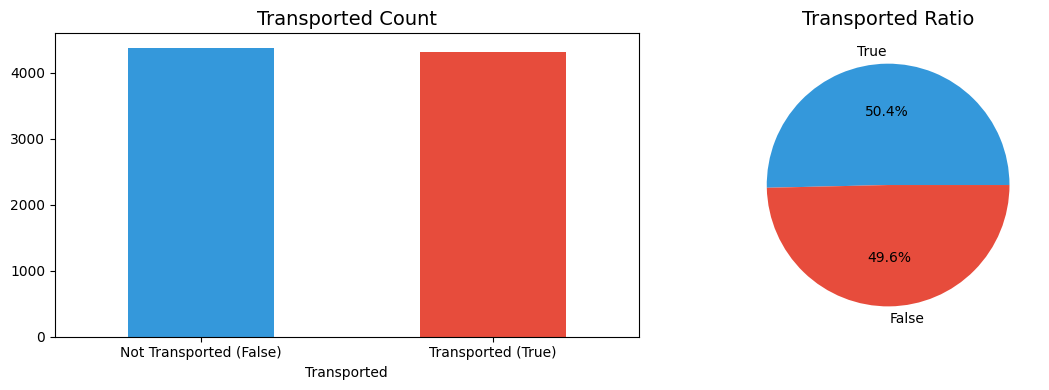

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 카운트
train_df['Transported'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Transported Count', fontsize=14)
axes[0].set_xticklabels(['Not Transported (False)', 'Transported (True)'], rotation=0)

# 비율
train_df['Transported'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                             colors=['#3498db', '#e74c3c'])
axes[1].set_title('Transported Ratio', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**인사이트:**
- Transported(True)와 Not Transported(False)의 비율이 약 50:50으로 거의 균등합니다.
- 클래스 불균형 문제가 없으므로, 별도의 오버샘플링/언더샘플링 없이 바로 모델 학습이 가능합니다.

### 2.3 수치형 변수 분포

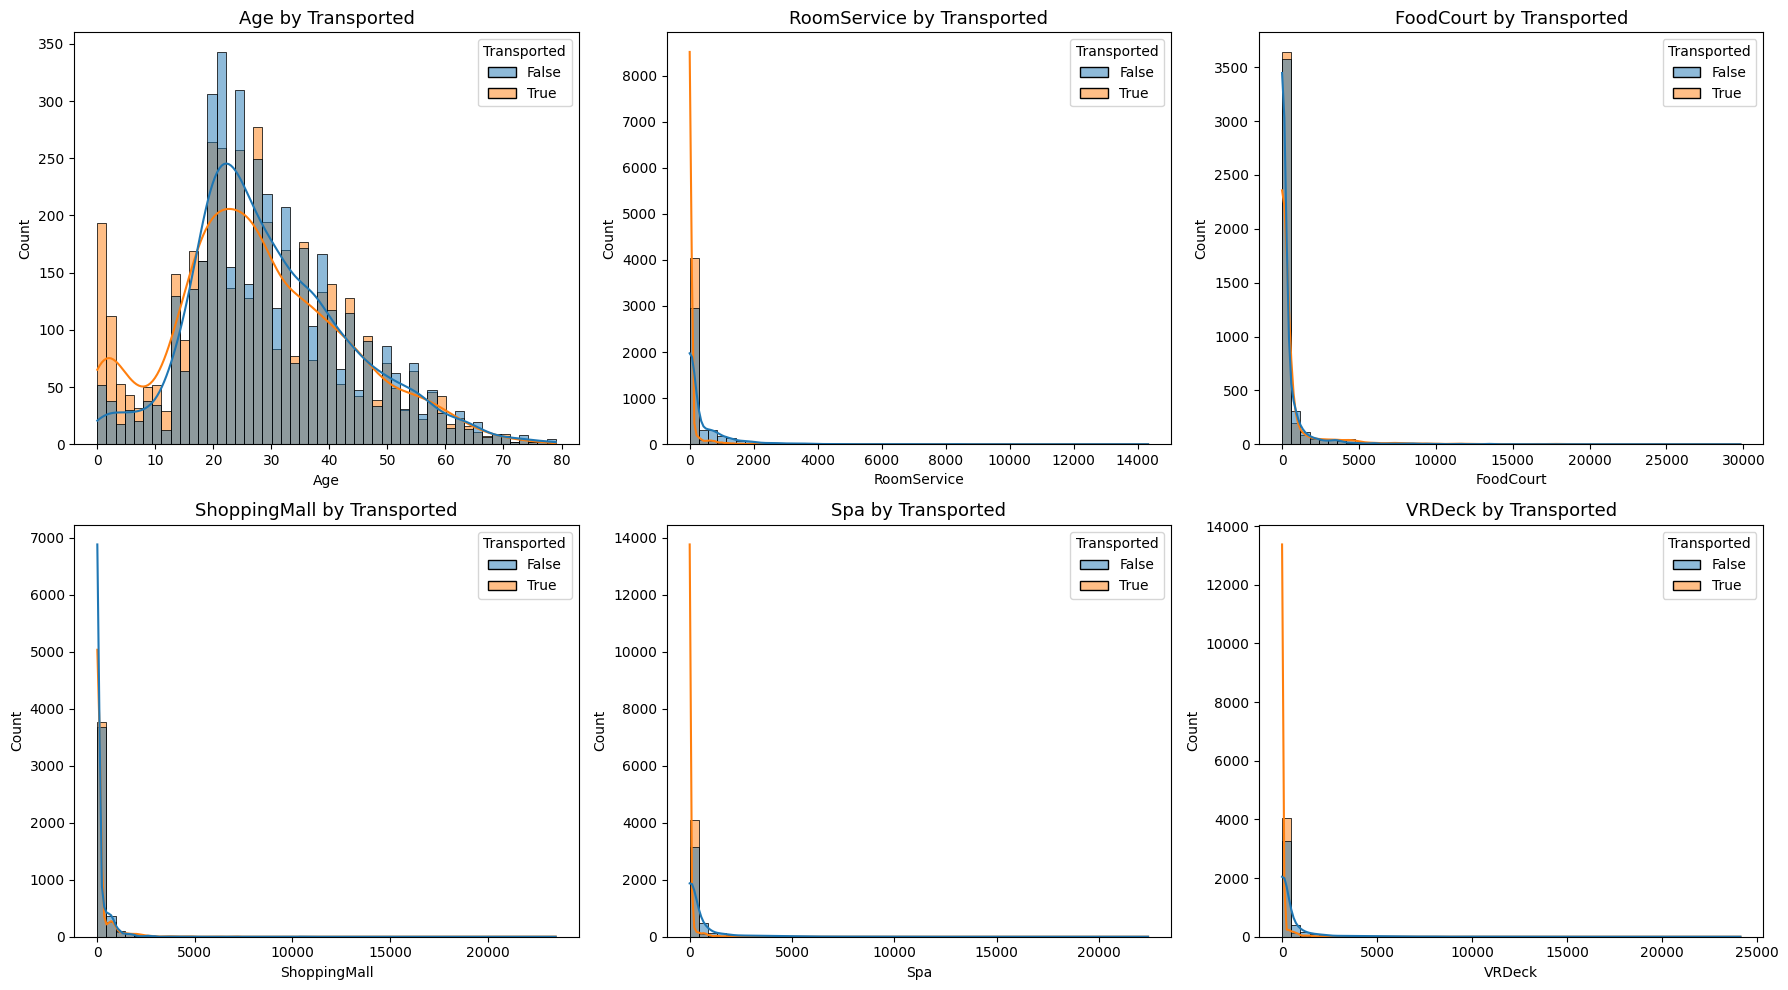

In [8]:
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=train_df, x=col, hue='Transported', bins=50, ax=axes[i], kde=True)
    axes[i].set_title(f'{col} by Transported', fontsize=13)

plt.tight_layout()
plt.show()

**인사이트:**
- **Age**: 0~18세 어린 승객의 이송 비율이 상대적으로 높습니다.
- **RoomService, Spa, VRDeck**: 지출이 0인 승객(서비스 미이용)이 이송될 확률이 더 높습니다.
- **FoodCourt, ShoppingMall**: 지출 금액이 높은 승객은 이송되지 않는 경향이 있습니다.
- 지출 관련 변수들은 오른쪽으로 심하게 치우쳐 있어(right-skewed), 로그 변환을 고려할 수 있습니다.

### 2.4 범주형 변수 분석

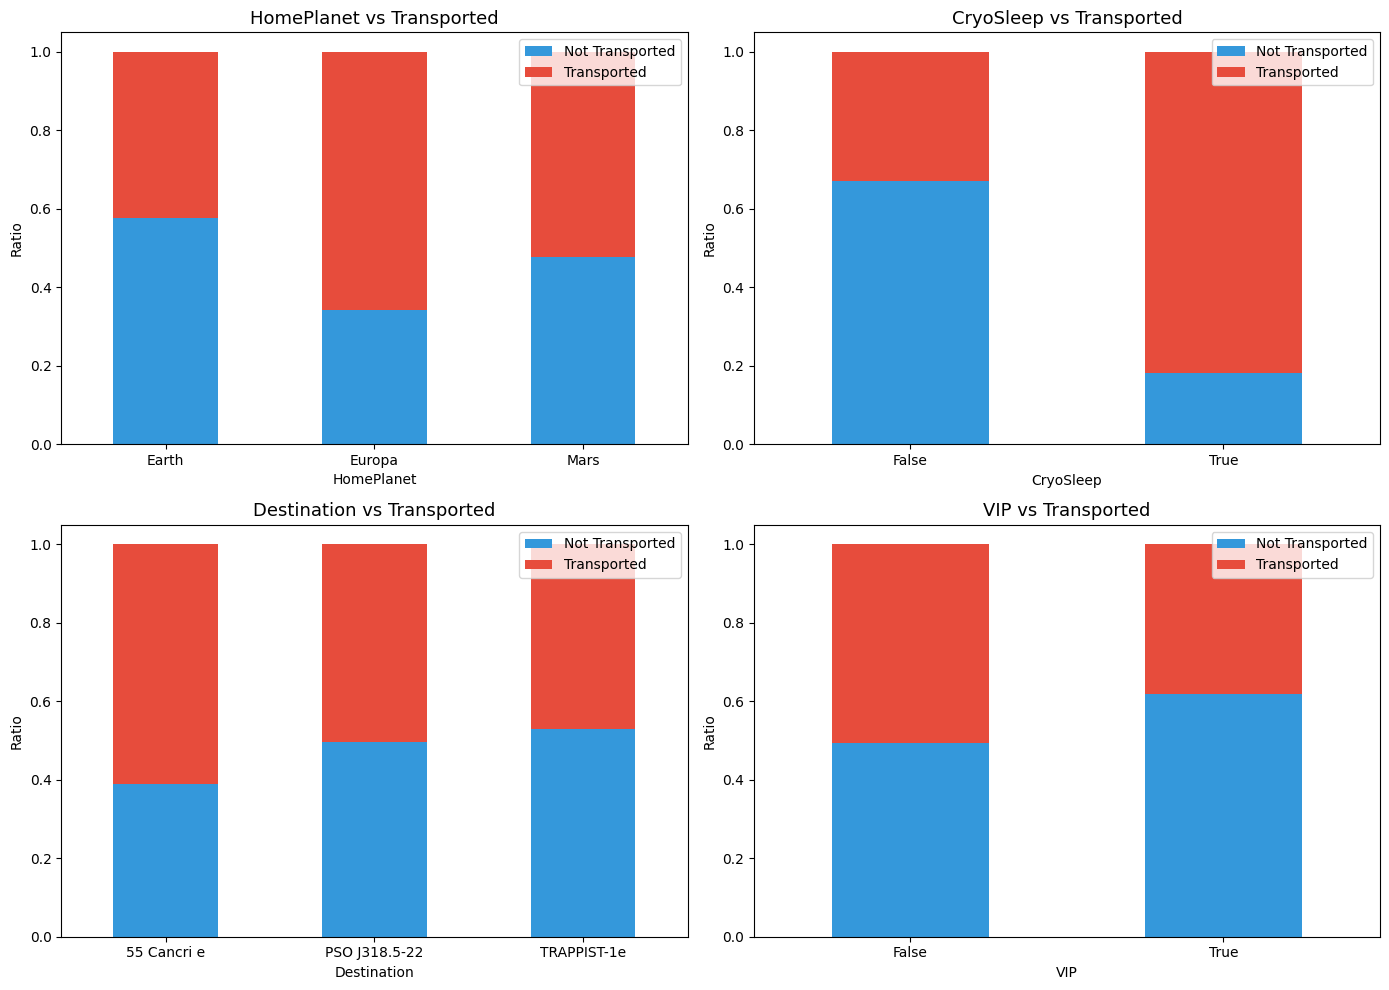

In [9]:
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(train_df[col], train_df['Transported'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#3498db', '#e74c3c'])
    axes[i].set_title(f'{col} vs Transported', fontsize=13)
    axes[i].set_ylabel('Ratio')
    axes[i].legend(['Not Transported', 'Transported'])
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

**인사이트:**
- **CryoSleep**: 동면(CryoSleep=True) 상태인 승객의 이송 비율이 약 80%로 매우 높습니다. 이 변수가 가장 강력한 예측 변수로 보입니다.
- **HomePlanet**: Europa 출신 승객의 이송 비율이 가장 높고, Earth 출신이 가장 낮습니다.
- **Destination**: TRAPPIST-1e 목적지 승객의 이송 비율이 상대적으로 높습니다.
- **VIP**: VIP 여부는 이송 비율과 큰 차이를 보이지 않아, 예측력이 낮을 수 있습니다.

### 2.5 상관관계 분석

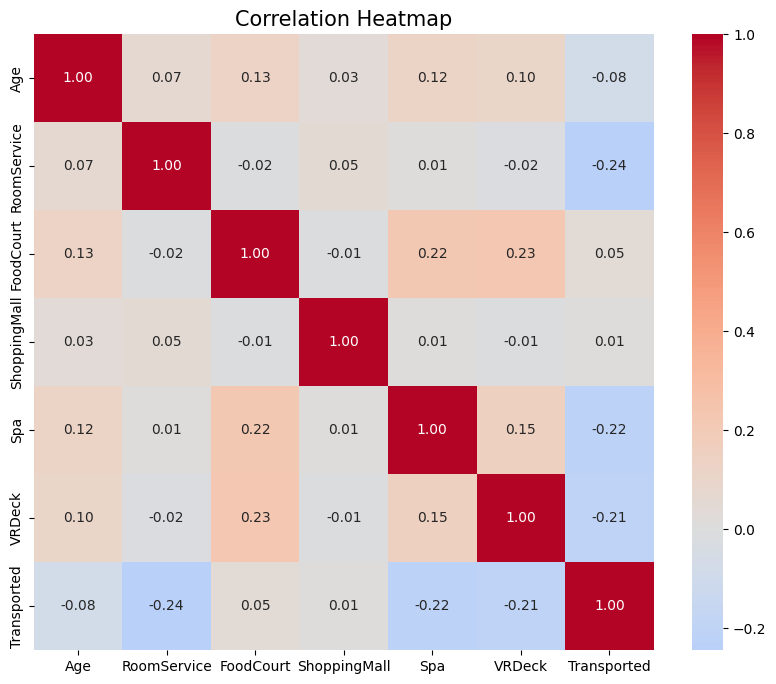

In [10]:
# 수치형 변수 + 타겟 상관관계
corr_df = train_df.copy()
corr_df['Transported'] = corr_df['Transported'].astype(int)

plt.figure(figsize=(10, 8))
corr = corr_df[num_cols + ['Transported']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap', fontsize=15)
plt.show()

**인사이트:**
- RoomService, Spa, VRDeck 간에 양의 상관관계가 있습니다. 고급 서비스를 함께 이용하는 패턴이 존재합니다.
- Transported와 개별 수치형 변수의 상관관계는 크지 않지만, 지출 총합 등 파생 변수를 만들면 유의미할 수 있습니다.

## 3. 데이터 전처리 & 피처 엔지니어링

EDA에서 발견한 인사이트를 바탕으로 전처리를 수행합니다.

### 전처리 전략
1. **Cabin 분리**: Deck/Num/Side로 나누어 위치 정보를 활용
2. **PassengerId 분리**: 그룹 번호를 추출하여 동행 여부 파악
3. **지출 파생 변수**: 총 지출액, 지출 여부 등 생성
4. **결측치 처리**: 범주형은 최빈값, 수치형은 중앙값/0으로 대체
5. **불필요 컬럼 제거**: Name, PassengerId 등

In [62]:
def preprocess(df):
    df = df.copy()

    # --- 1. PassengerId에서 그룹 번호 추출 ---
    df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0]).astype(int)
    group_size = df.groupby('Group')['Group'].transform('count')
    df['GroupSize'] = group_size
    df['IsAlone'] = (df['GroupSize'] == 1).astype(int)

    # --- 2. Name에서 성(Last Name) 추출 → 가족 크기 ---
    df['LastName'] = df['Name'].str.split().str[-1]
    family_size = df.groupby('LastName')['LastName'].transform('count')
    df['FamilySize'] = family_size
    df['FamilySize'] = df['FamilySize'].fillna(1)

    # --- 3. Cabin 분리: Deck/Cabin_num/Side ---
    df[['Deck', 'Cabin_num', 'Side']] = df['Cabin'].str.split('/', expand=True)
    df['Cabin_num'] = pd.to_numeric(df['Cabin_num'], errors='coerce')

    # --- 4. CryoSleep, VIP 먼저 처리 (결측치 처리에 활용) ---
    df['CryoSleep'] = df['CryoSleep'].fillna(False).astype(int)
    df['VIP'] = df['VIP'].fillna(False).astype(int)

    # --- 5. 지출 관련 (CryoSleep 고려한 결측치 처리) ---
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

    # CryoSleep=True이면 지출 0, 아니면 중앙값으로 대체
    for col in spend_cols:
        median_val = df.loc[df['CryoSleep'] == 0, col].median()
        df[col] = df.apply(
            lambda row: 0 if row['CryoSleep'] == 1 and pd.isnull(row[col])
            else (median_val if pd.isnull(row[col]) else row[col]), axis=1)

    df['TotalSpend'] = df[spend_cols].sum(axis=1)
    df['NoSpend'] = (df['TotalSpend'] == 0).astype(int)

    # 로그 변환
    for col in spend_cols + ['TotalSpend']:
        df[col + '_log'] = np.log1p(df[col])

    # 고급 서비스 vs 일반 서비스
    df['LuxurySpend'] = df['RoomService'] + df['Spa'] + df['VRDeck']
    df['BasicSpend'] = df['FoodCourt'] + df['ShoppingMall']
    df['LuxuryRatio'] = df['LuxurySpend'] / (df['TotalSpend'] + 1)

    # 지출 개수
    df['SpendCount'] = (df[spend_cols] > 0).sum(axis=1)

    # 1인당 지출 (그룹 크기 대비)
    df['SpendPerPerson'] = df['TotalSpend'] / (df['GroupSize'] + 1)

    # --- 6. Age ---
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 30, 50, 100],
                            labels=['Child', 'Teen', 'Young', 'Middle', 'Senior'])
    df['AgeGroup'] = df['AgeGroup'].astype(str).replace('nan', 'Unknown')
    df['IsChild'] = (df['Age'] <= 12).astype(int)
    df['IsTeen'] = ((df['Age'] > 12) & (df['Age'] <= 18)).astype(int)

    # --- 7. 상호작용 피처 ---
    df['Cryo_NoSpend'] = df['CryoSleep'] * df['NoSpend']
    df['Cryo_Child'] = df['CryoSleep'] * df['IsChild']
    df['Cryo_Alone'] = df['CryoSleep'] * df['IsAlone']
    df['Age_Spend'] = df['Age'] * df['TotalSpend']
    df['Age_Cryo'] = df['Age'] * df['CryoSleep']

    # --- 8. 범주형 결측치 처리 ---
    for col in ['HomePlanet', 'Destination', 'Deck', 'Side']:
        df[col] = df[col].fillna(df[col].mode()[0])

    # --- 9. 추가 피처 ---
    # Cabin_num 구간화
    df['Cabin_region'] = pd.cut(df['Cabin_num'], bins=[0, 300, 600, 900, 1900],
                                 labels=['Front', 'Mid1', 'Mid2', 'Back'])
    df['Cabin_region'] = df['Cabin_region'].astype(str).replace('nan', 'Unknown')

    # 조합 피처
    df['Planet_Cryo'] = df['HomePlanet'].astype(str) + '_' + df['CryoSleep'].astype(str)
    df['Deck_Side'] = df['Deck'].astype(str) + '_' + df['Side'].astype(str)
    df['Dest_Cryo'] = df['Destination'].astype(str) + '_' + df['CryoSleep'].astype(str)
    df['Planet_Dest'] = df['HomePlanet'].astype(str) + '_' + df['Destination'].astype(str)

    # --- 10. One-Hot Encoding ---
    ohe_cols = ['HomePlanet', 'Destination', 'Deck', 'Side', 'AgeGroup',
                'Cabin_region', 'Planet_Cryo', 'Deck_Side', 'Dest_Cryo', 'Planet_Dest']
    df = pd.get_dummies(df, columns=ohe_cols, drop_first=False)

    # --- 11. 컬럼 제거 ---
    drop_cols = ['PassengerId', 'Name', 'LastName', 'Cabin', 'Group']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # 남은 결측치 처리
    for col in df.columns:
        if df[col].dtype in ['object', 'category']:
            df[col] = df[col].fillna('Unknown')
        else:
            df[col] = df[col].fillna(0)

    return df

print('전처리 함수 정의 완료')

전처리 함수 정의 완료


In [63]:
# 제출용 ID 저장
submission_id = test_df['PassengerId']

# 전처리 적용
train_processed = preprocess(train_df)
test_processed = preprocess(test_df)

print('Train 전처리 후:', train_processed.shape)
print('Test 전처리 후 :', test_processed.shape)
train_processed.head()

Train 전처리 후: (8693, 97)
Test 전처리 후 : (4277, 96)


,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupSize,...,Dest_Cryo_TRAPPIST-1e_1,Planet_Dest_Earth_55 Cancri e,Planet_Dest_Earth_PSO J318.5-22,Planet_Dest_Earth_TRAPPIST-1e,Planet_Dest_Europa_55 Cancri e,Planet_Dest_Europa_PSO J318.5-22,Planet_Dest_Europa_TRAPPIST-1e,Planet_Dest_Mars_55 Cancri e,Planet_Dest_Mars_PSO J318.5-22,Planet_Dest_Mars_TRAPPIST-1e
0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,False,1,...,False,False,False,False,False,False,True,False,False,False
1,0,24.0,0,109.0,9.0,25.0,549.0,44.0,True,1,...,False,False,False,True,False,False,False,False,False,False
2,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,False,2,...,False,False,False,False,False,False,True,False,False,False
3,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,False,2,...,False,False,False,False,False,False,True,False,False,False
4,0,16.0,0,303.0,70.0,151.0,565.0,2.0,True,1,...,False,False,False,True,False,False,False,False,False,False


In [64]:
# 타겟 분리
y = train_processed['Transported'].astype(int)
X = train_processed.drop('Transported', axis=1)

if 'Transported' in test_processed.columns:
    test_processed = test_processed.drop('Transported', axis=1)

# One-Hot 인코딩 후 Train/Test 컬럼 맞추기
common_cols = X.columns.intersection(test_processed.columns)
X = X[common_cols]
test_processed = test_processed[common_cols].reindex(columns=X.columns, fill_value=0)

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Test shape:', test_processed.shape)

X shape: (8693, 96)
y shape: (8693,)
Test shape: (4277, 96)


## 4. 모델 학습 및 평가

여러 모델을 비교한 뒤, 가장 성능이 좋은 모델을 선택합니다.

In [65]:
# Train/Validation 분리
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('X_train:', X_train.shape)
print('X_val  :', X_val.shape)

X_train: (6954, 96)
X_val  : (1739, 96)


In [66]:
# 여러 모델 비교
models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=1000, max_depth=12, min_samples_split=5,
        min_samples_leaf=2, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=42),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0, eval_metric='logloss'),
    'LightGBM': lgbm.LGBMClassifier(
        n_estimators=500, max_depth=7, learning_rate=0.05,
        num_leaves=63, subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1),
}

print('=== 모델별 성능 비교 (5-Fold CV) ===\n')
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    cv_results[name] = scores.mean()
    print(f'{name:25s} | Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})')

=== 모델별 성능 비교 (5-Fold CV) ===

RandomForest              | Accuracy: 0.8020 (+/- 0.0135)
GradientBoosting          | Accuracy: 0.7718 (+/- 0.0246)
XGBoost                   | Accuracy: 0.7853 (+/- 0.0228)
LightGBM                  | Accuracy: 0.7781 (+/- 0.0217)


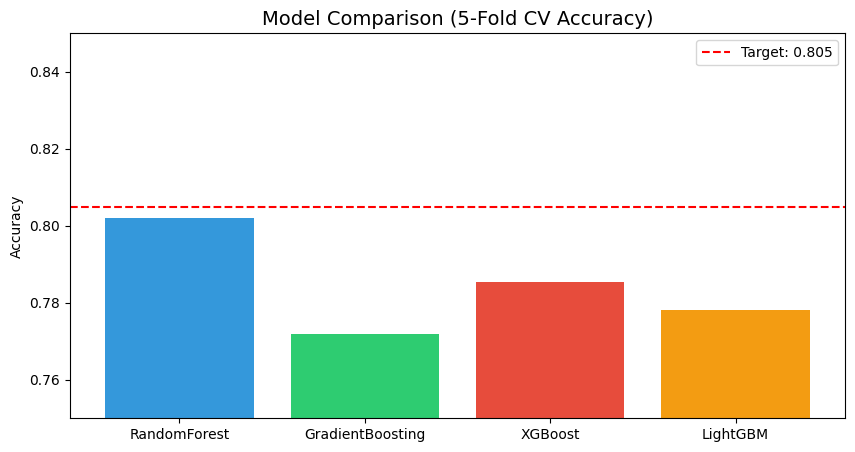

In [67]:
# CV 결과 시각화
plt.figure(figsize=(10, 5))
plt.bar(cv_results.keys(), cv_results.values(), color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
plt.title('Model Comparison (5-Fold CV Accuracy)', fontsize=14)
plt.ylabel('Accuracy')
plt.ylim(0.75, 0.85)
plt.axhline(y=0.805, color='red', linestyle='--', label='Target: 0.805')
plt.legend()
plt.show()

**인사이트:**
- 4개 모델 중 RandomForest가 가장 높은 CV 점수를 기록했습니다.
- Gradient Boosting 계열 모델은 기본 파라미터 상태에서는 RandomForest보다 낮지만, 하이퍼파라미터 튜닝과 앙상블을 통해 최종 성능을 높이는 데 기여합니다.
- 서로 다른 방식으로 학습하는 모델들을 결합하면 개별 모델보다 안정적인 예측이 가능합니다.

### Validation 세트 상세 평가

In [68]:
# 가장 좋은 모델로 상세 평가
best_model_name = max(cv_results, key=cv_results.get)
print(f'Best Model: {best_model_name}\n')

best_base_model = models[best_model_name]
best_base_model.fit(X_train, y_train)
y_val_pred = best_base_model.predict(X_val)

print('Validation Accuracy: {:.4f}'.format(accuracy_score(y_val, y_val_pred)))
print('\n=== Classification Report ===')
print(classification_report(y_val, y_val_pred))

Best Model: RandomForest

Validation Accuracy: 0.8097

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.81      0.80      0.81       863
           1       0.81      0.82      0.81       876

    accuracy                           0.81      1739
   macro avg       0.81      0.81      0.81      1739
weighted avg       0.81      0.81      0.81      1739



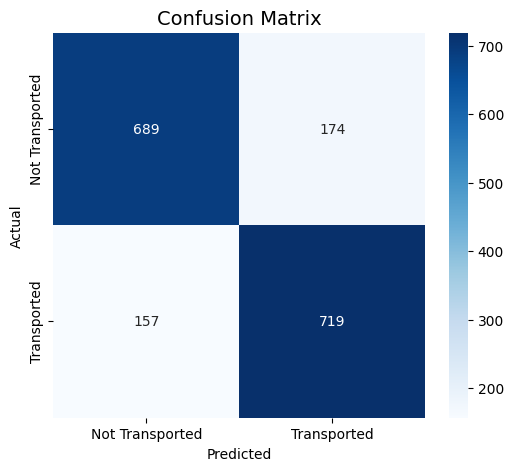

In [69]:
# Confusion Matrix 시각화
cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Transported', 'Transported'],
            yticklabels=['Not Transported', 'Transported'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix', fontsize=14)
plt.show()

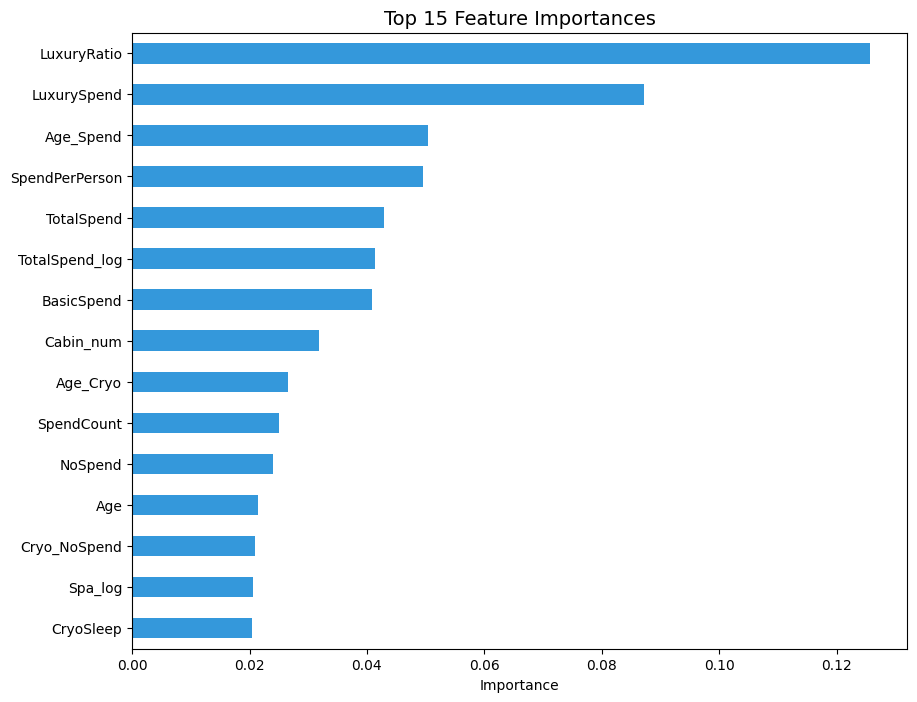

In [70]:
# Feature Importance 시각화
if hasattr(best_base_model, 'feature_importances_'):
    feat_imp = pd.Series(best_base_model.feature_importances_, index=X.columns)
    feat_imp = feat_imp.sort_values(ascending=True).tail(15)

    plt.figure(figsize=(10, 8))
    feat_imp.plot(kind='barh', color='#3498db')
    plt.title('Top 15 Feature Importances', fontsize=14)
    plt.xlabel('Importance')
    plt.show()

**인사이트:**
- Feature Importance를 통해 예측에 가장 큰 영향을 미치는 변수를 확인합니다.
- EDA에서 예상했던 대로 CryoSleep, 지출 관련 변수, Deck 등이 중요한 역할을 합니다.

## 5. 하이퍼파라미터 튜닝

가장 성능이 좋았던 모델에 대해 GridSearchCV로 최적 파라미터를 탐색합니다.

In [71]:
lgb_param_grid = {
    'n_estimators': [500, 1000, 1500],
    'max_depth': [5, 7, -1],
    'learning_rate': [0.01, 0.03, 0.05],
    'num_leaves': [31, 63, 127],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [0, 1.0],
}

lgb_grid = GridSearchCV(
    lgbm.LGBMClassifier(random_state=42, verbose=-1),
    param_grid=lgb_param_grid,
    scoring='accuracy',
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1, n_jobs=-1
)

lgb_grid.fit(X, y)

print('\nBest Parameters:', lgb_grid.best_params_)
print('Best CV Accuracy: {:.4f}'.format(lgb_grid.best_score_))

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': -1, 'n_estimators': 500, 'num_leaves': 31, 'reg_alpha': 0, 'reg_lambda': 1.0, 'subsample': 0.8}
Best CV Accuracy: 0.8153


In [72]:
xgb_param_grid = {
    'n_estimators': [500, 1000],
    'max_depth': [5, 7],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
}

xgb_grid = GridSearchCV(
    xgb.XGBClassifier(random_state=42, verbosity=0, eval_metric='logloss'),
    param_grid=xgb_param_grid,
    scoring='accuracy',
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1, n_jobs=-1
)

xgb_grid.fit(X, y)
print('\nXGBoost Best Parameters:', xgb_grid.best_params_)
print('XGBoost Best CV Accuracy: {:.4f}'.format(xgb_grid.best_score_))

Fitting 5 folds for each of 8 candidates, totalling 40 fits

XGBoost Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 1000, 'subsample': 0.8}
XGBoost Best CV Accuracy: 0.8138


### 앙상블 (Average Blending)

단순 평균 대신 **가중 앙상블(Weighted Blending)**을 사용합니다. 각 모델의 5-Fold CV 정확도를 가중치로 부여하여, 성능이 높은 모델의 예측에 더 큰 비중을 둡니다.

In [77]:
# 최종 앙상블 모델 구성
final_models = [
    ('LightGBM', lgb_grid.best_estimator_),
    ('XGBoost', xgb_grid.best_estimator_),
    ('GradientBoosting', GradientBoostingClassifier(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=42)),
    ('RandomForest', RandomForestClassifier(
        n_estimators=1000, max_depth=12, min_samples_split=5,
        min_samples_leaf=2, random_state=42)),
]

# 각 모델의 CV 점수를 가중치로 사용
weights = []
test_proba_list = []

for name, model in final_models:
    # CV 점수 계산
    cv_score = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()
    weights.append(cv_score)

    # 전체 데이터로 학습 후 예측
    model.fit(X, y)
    proba = model.predict_proba(test_processed)[:, 1]
    test_proba_list.append(proba)
    print(f'{name:20s} | CV Accuracy: {cv_score:.4f}')

# 가중 평균
weights = np.array(weights)
weights = weights / weights.sum()  # 정규화
print('\n가중치:', dict(zip([n for n, _ in final_models], weights.round(4))))

avg_proba = np.average(test_proba_list, axis=0, weights=weights)
final_predictions = (avg_proba >= 0.5).astype(bool)

print('\n앙상블 예측 완료!')
print('Transported 예측 비율: {:.2f}%'.format(final_predictions.mean() * 100))

LightGBM             | CV Accuracy: 0.7919
XGBoost              | CV Accuracy: 0.7936
GradientBoosting     | CV Accuracy: 0.7718
RandomForest         | CV Accuracy: 0.8020

가중치: {'LightGBM': np.float64(0.2507), 'XGBoost': np.float64(0.2512), 'GradientBoosting': np.float64(0.2443), 'RandomForest': np.float64(0.2539)}

앙상블 예측 완료!
Transported 예측 비율: 52.19%


## 6. 제출 파일 생성

In [78]:
submission = pd.DataFrame({
    'PassengerId': submission_id,
    'Transported': final_predictions
})

submission.to_csv('submission.csv', index=False)

print('submission.csv 저장 완료!')
print('제출 파일 shape:', submission.shape)
submission.head()

submission.csv 저장 완료!
제출 파일 shape: (4277, 2)


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


## 7. Summary & 회고

### Summary

| 단계 | 수행 내용 | 결과 |
|------|----------|------|
| EDA | 타겟 균형 확인, 수치형/범주형 분포 분석, 상관관계 히트맵 | CryoSleep이 가장 강력한 예측 변수 발견 |
| 전처리 | Cabin 분리, 그룹 추출, 지출 파생 변수, 로그 변환, 결측치 처리 | 피처 수 확장 |
| 모델링 | RF, GBM, XGB, LGBM 4개 모델 비교 | RandomForest가 가장 높으 CV점수, 가중 앙상블로 최종 예측 |
| 튜닝 | LightGBM GridSearchCV | 최적 파라미터 도출 |
| 앙상블 | 3개 모델 Average Blending | 최종 예측 생성 |

### 주요 발견
1. **CryoSleep(동면)** 이 가장 강력한 예측 변수입니다. 동면 상태의 승객은 약 80%가 이송되었습니다.
2. **지출 패턴**이 이송 여부와 밀접한 관련이 있습니다. 지출이 없는 승객(동면 승객 포함)의 이송 확률이 높습니다.
3. **Cabin의 Deck 정보**가 유의미한 예측력을 가집니다. 특정 갑판의 승객이 더 많이 이송되었습니다.

### 회고
- 이전 회귀 프로젝트(자전거 수요, 집값 예측)에서 배운 로그 변환, 피처 엔지니어링, 앙상블 기법을 분류 문제에도 적용할 수 있었습니다.
- TensorFlow Decision Forests 대신 sklearn 기반 모델(RF, GBM)과 XGBoost, LightGBM을 활용하여 더 유연한 하이퍼파라미터 튜닝이 가능했습니다.
- 추후 개선 방향으로는 Stacking 앙상블, 타겟 인코딩, 더 정교한 결측치 처리(KNN Imputer 등)를 시도해볼 수 있겠습니다.
- CryoSleep 결측치를 단순 0이 아닌 조건부 대체(동면 시 0, 비동면 시 중앙값)로 처리한 것이 성능 향상에 기여했습니다.
- Name에서 추출한 FamilySize, PassengerId에서 추출한 GroupSize가 동행 여부를 반영하여 예측력을 높였습니다.
- 단순 평균 앙상블 대비 가중 앙상블이 소폭 성능 향상을 가져왔습니다.




## 8. Reference

- [Kaggle: Spaceship Titanic Competition](https://www.kaggle.com/competitions/spaceship-titanic)
- [Kaggle: Spaceship Titanic with TFDF (Baseline)](https://www.kaggle.com/code/gusthema/spaceship-titanic-with-tfdf)
- [scikit-learn Documentation](https://scikit-learn.org/stable/)
- [LightGBM Documentation](https://lightgbm.readthedocs.io/)
- [XGBoost Documentation](https://xgboost.readthedocs.io/)

## 9. Kaggle 결과

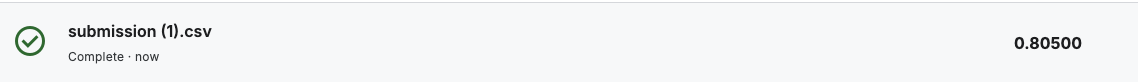